<a href="https://colab.research.google.com/github/Taniya-roy20/ML-PROJECT/blob/main/comparison_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()   # a button will appear -> choose apple.csv from your PC

CSV_PATH = list(uploaded.keys())[0]
print("Loaded file:", CSV_PATH)

Saving FAOSTAT_data_en_8-19-2026.csv to FAOSTAT_data_en_8-19-2026.csv
Loaded file: FAOSTAT_data_en_8-19-2026.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_data(path):
    df = pd.read_csv(path)

    year_col = df.columns[9]
    yield_col = df.columns[11]

    data = df[[year_col, yield_col]].copy()
    data.columns = ["year", "yield"]

    data["year"] = pd.to_numeric(data["year"], errors="coerce")
    data["yield"] = pd.to_numeric(data["yield"], errors="coerce")
    data = data.dropna()

    data["year"] = data["year"].astype(int)

    return data


def train_linear_regression(years, yields):
    slope, intercept = np.polyfit(years, yields, 1)
    return slope, intercept


def predict(slope, intercept, year):
    return slope * year + intercept


# -------------------------------
# Evaluation Metrics
# -------------------------------

def calculate_mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


def calculate_rmse(actual, predicted):
    mse = calculate_mse(actual, predicted)
    return np.sqrt(mse)


def calculate_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))


def calculate_r2(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)

    return 1 - (ss_res / ss_tot)

Slope     : 70.6068
Intercept : -134691.3750

----- Model Evaluation -----
MSE       : 650847.4664
RMSE      : 806.7512
MAE       : 601.0443
R² Score  : 0.7233

----- Predicted Yield -----
2027 -> 8428.53 kg/ha
2028 -> 8499.14 kg/ha
2029 -> 8569.74 kg/ha
2030 -> 8640.35 kg/ha

Graph saved to regression_plot.png


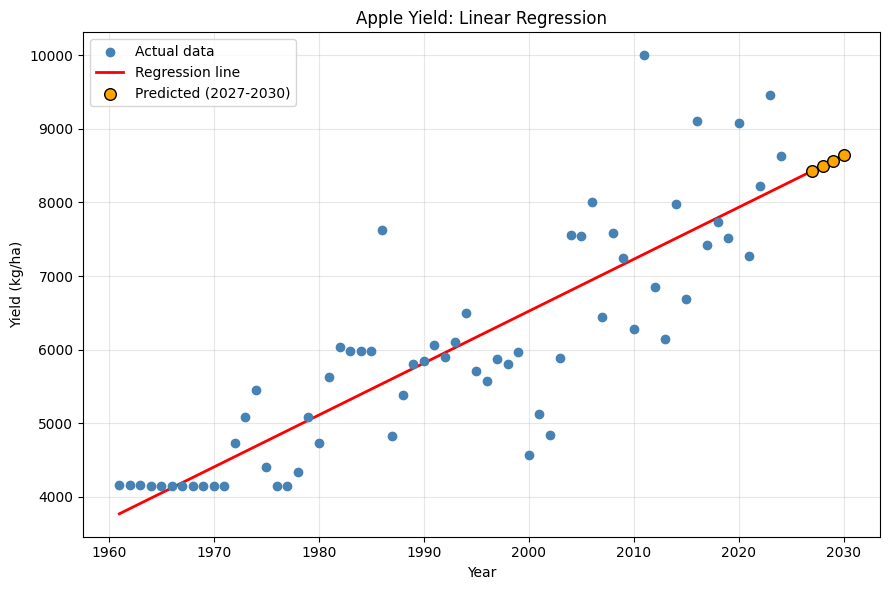

In [3]:
data = load_data(CSV_PATH)

if data.empty:
    print("No data found!")

else:
    years = data["year"].to_numpy()
    yields = data["yield"].to_numpy()

    # Train Linear Regression
    slope, intercept = train_linear_regression(years, yields)

    # Predictions on historical data
    predicted_yields = predict(slope, intercept, years)

    # Calculate evaluation metrics
    mse = calculate_mse(yields, predicted_yields)
    rmse = calculate_rmse(yields, predicted_yields)
    mae = calculate_mae(yields, predicted_yields)
    r2 = calculate_r2(yields, predicted_yields)

    # Display model parameters
    print(f"Slope     : {slope:.4f}")
    print(f"Intercept : {intercept:.4f}")

    # Display evaluation metrics
    print("\n----- Model Evaluation -----")
    print(f"MSE       : {mse:.4f}")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAE       : {mae:.4f}")
    print(f"R² Score  : {r2:.4f}")

    # -------------------------------
    # Future Predictions
    # -------------------------------

    predict_years = np.arange(2027, 2031)
    predict_yields = predict(slope, intercept, predict_years)

    print("\n----- Predicted Yield -----")

    for y, p in zip(predict_years, predict_yields):
        print(f"{y} -> {p:.2f} kg/ha")

    # -------------------------------
    # Plot
    # -------------------------------

    plt.figure(figsize=(9, 6))

    plt.scatter(
        years,
        yields,
        color="steelblue",
        label="Actual data",
        zorder=3
    )

    line_years = np.arange(
        years.min(),
        predict_years.max() + 1
    )

    line_yields = predict(
        slope,
        intercept,
        line_years
    )

    plt.plot(
        line_years,
        line_yields,
        color="red",
        linewidth=2,
        label="Regression line"
    )

    plt.scatter(
        predict_years,
        predict_yields,
        color="orange",
        edgecolor="black",
        s=70,
        label="Predicted (2027-2030)",
        zorder=4
    )

    plt.title("Apple Yield: Linear Regression")
    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig("regression_plot.png", dpi=150)

    print("\nGraph saved to regression_plot.png")

    plt.show()

In [4]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving FAOSTAT_data_en_8-19-2026.csv to FAOSTAT_data_en_8-19-2026 (1).csv
Uploaded file: FAOSTAT_data_en_8-19-2026 (1).csv


In [5]:
import pandas as pd

# Dataset load karke unique Areas count karte hain
df = pd.read_csv('FAOSTAT_data_en_8-19-2026.csv')
print("Unique Areas in dataset:\n", df['Area'].unique())
print("\nTotal Unique Areas:", df['Area'].nunique())

Unique Areas in dataset:
 ['India']

Total Unique Areas: 1


----- Polynomial Regression -----
Polynomial Degree : 2

Model Equation:
        2
0.4621 x - 1771 x + 1.7e+06

----- Model Evaluation -----
MSE      : 630972.4573
RMSE     : 794.3377
MAE      : 593.8240
R² Score : 0.7317

----- Predicted Yield -----
2027 -> 8820.81 kg/ha
2028 -> 8923.77 kg/ha
2029 -> 9027.64 kg/ha
2030 -> 9132.44 kg/ha

Graph saved to polynomial_regression_plot.png


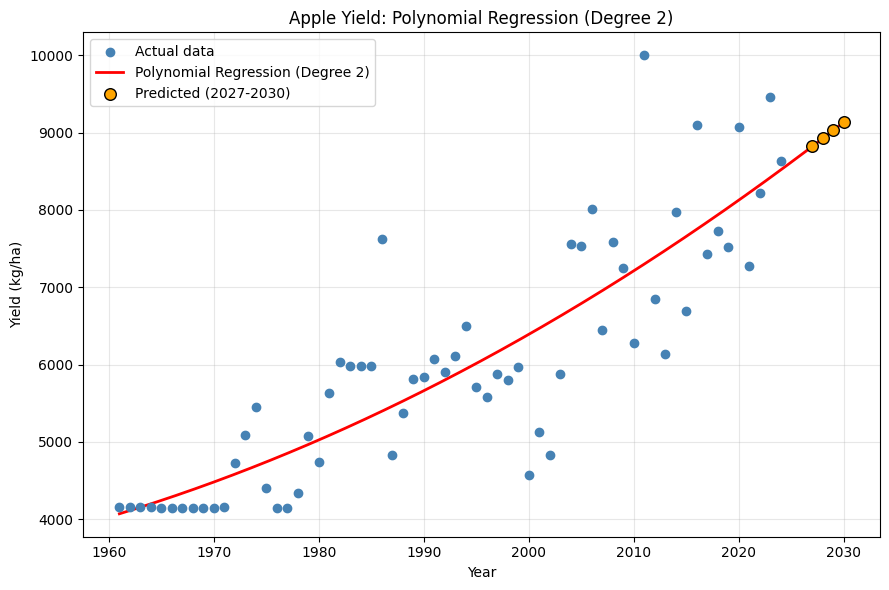

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------
# Load Dataset
# --------------------------------

def load_data(path):
    df = pd.read_csv(path)

    year_col = df.columns[9]
    yield_col = df.columns[11]

    data = df[[year_col, yield_col]].copy()
    data.columns = ["year", "yield"]

    data["year"] = pd.to_numeric(data["year"], errors="coerce")
    data["yield"] = pd.to_numeric(data["yield"], errors="coerce")

    data = data.dropna()

    data["year"] = data["year"].astype(int)

    return data


# --------------------------------
# Polynomial Regression
# --------------------------------

def train_polynomial_regression(years, yields, degree):
    coefficients = np.polyfit(years, yields, degree)
    model = np.poly1d(coefficients)

    return model


def predict(model, years):
    return model(years)


# --------------------------------
# Evaluation Metrics
# --------------------------------

def calculate_mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


def calculate_rmse(actual, predicted):
    mse = calculate_mse(actual, predicted)
    return np.sqrt(mse)


def calculate_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))


def calculate_r2(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)

    return 1 - (ss_res / ss_tot)


# --------------------------------
# Main Program
# --------------------------------

CSV_PATH = "FAOSTAT_data_en_8-19-2026.csv"

# Change this to 3 or 4 if required
DEGREE = 2

data = load_data(CSV_PATH)


if data.empty:

    print("No data found!")

else:

    years = data["year"].to_numpy()
    yields = data["yield"].to_numpy()

    # Train Polynomial Regression
    model = train_polynomial_regression(
        years,
        yields,
        DEGREE
    )

    # Predictions for historical data
    predicted_yields = predict(
        model,
        years
    )

    # --------------------------------
    # Evaluation Metrics
    # --------------------------------

    mse = calculate_mse(
        yields,
        predicted_yields
    )

    rmse = calculate_rmse(
        yields,
        predicted_yields
    )

    mae = calculate_mae(
        yields,
        predicted_yields
    )

    r2 = calculate_r2(
        yields,
        predicted_yields
    )

    # --------------------------------
    # Display Results
    # --------------------------------

    print("----- Polynomial Regression -----")

    print(f"Polynomial Degree : {DEGREE}")

    print("\nModel Equation:")
    print(model)

    print("\n----- Model Evaluation -----")

    print(f"MSE      : {mse:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"R² Score : {r2:.4f}")

    # --------------------------------
    # Future Predictions
    # --------------------------------

    predict_years = np.arange(2027, 2031)

    predict_yields = predict(
        model,
        predict_years
    )

    print("\n----- Predicted Yield -----")

    for year, prediction in zip(
        predict_years,
        predict_yields
    ):
        print(
            f"{year} -> {prediction:.2f} kg/ha"
        )

    # --------------------------------
    # Plot
    # --------------------------------

    plt.figure(figsize=(9, 6))

    # Actual data
    plt.scatter(
        years,
        yields,
        color="steelblue",
        label="Actual data",
        zorder=3
    )

    # Smooth polynomial curve
    line_years = np.linspace(
        years.min(),
        predict_years.max(),
        500
    )

    line_yields = predict(
        model,
        line_years
    )

    plt.plot(
        line_years,
        line_yields,
        color="red",
        linewidth=2,
        label=f"Polynomial Regression (Degree {DEGREE})"
    )

    # Future predictions
    plt.scatter(
        predict_years,
        predict_yields,
        color="orange",
        edgecolor="black",
        s=70,
        label="Predicted (2027-2030)",
        zorder=4
    )

    plt.title(
        f"Apple Yield: Polynomial Regression (Degree {DEGREE})"
    )

    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "polynomial_regression_plot.png",
        dpi=150
    )

    print(
        "\nGraph saved to polynomial_regression_plot.png"
    )

    plt.show()

In [7]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving apple.csv to apple.csv
Uploaded file: apple.csv


Original Dataset Shape: (128, 12)

Processed Dataset:
   Year  Area_Harvested   Yield
0  1961         44500.0  4157.3
1  1962         38500.0  4155.8
2  1963         33700.0  4154.3
3  1964         26500.0  4150.9
4  1965         21700.0  4147.5

Number of Years: 64

Training Samples: 54
Testing Samples : 10


MULTIVARIATE LINEAR REGRESSION

Intercept:
-188941.2085

Coefficients:
Year : 98.420056
Area_Harvested : -0.006395

Model Equation:
Yield = -188941.2085 + (98.420056 × Year) + (-0.006395 × Area_Harvested)


-------------------------------------------------------
TRAINING METRICS
-------------------------------------------------------
MSE      : 624235.4723
RMSE     : 790.0857
MAE      : 582.6600
R² Score : 0.6235


-------------------------------------------------------
TESTING METRICS
-------------------------------------------------------
MSE      : 606414.7027
RMSE     : 778.7263
MAE      : 614.8514
R² Score : 0.2133


-------------------------------------------------------
AC

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


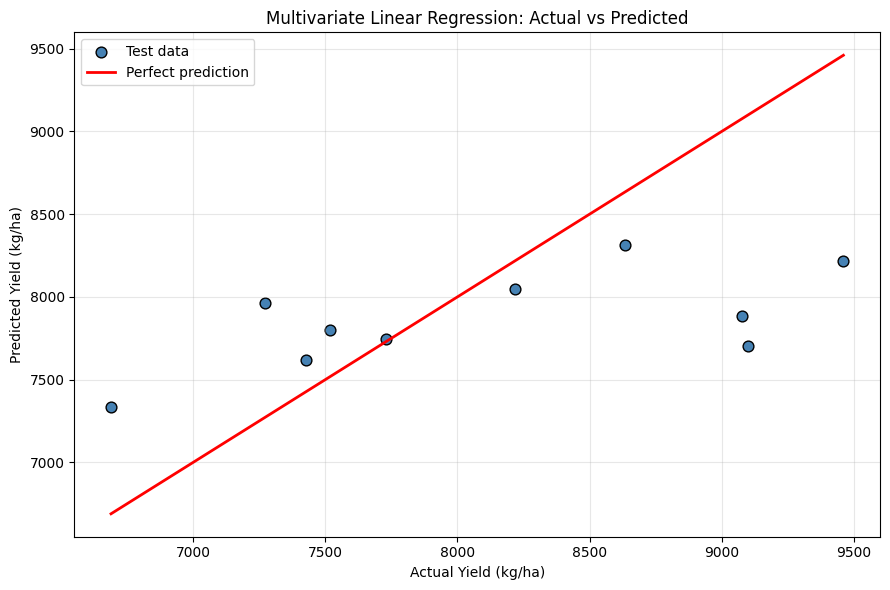

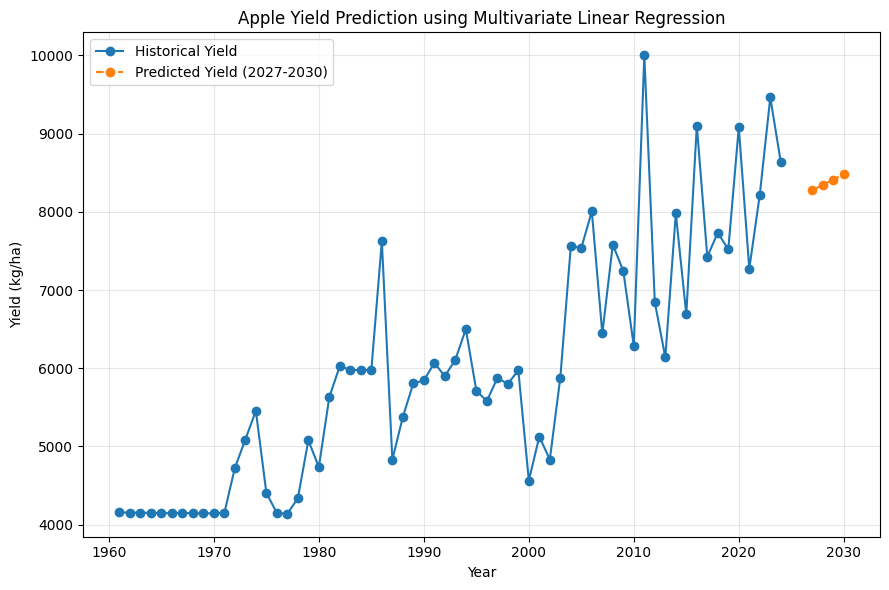


Graphs saved successfully!


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. LOAD DATA
# ============================================================

CSV_PATH = "apple.csv"

df = pd.read_csv(CSV_PATH)

print("Original Dataset Shape:", df.shape)


# ============================================================
# 2. SELECT REQUIRED COLUMNS
# ============================================================

data = df[["Element", "Year", "Value"]].copy()

data["Year"] = pd.to_numeric(
    data["Year"],
    errors="coerce"
)

data["Value"] = pd.to_numeric(
    data["Value"],
    errors="coerce"
)

data = data.dropna()


# ============================================================
# 3. SEPARATE AREA HARVESTED AND YIELD
# ============================================================

area_data = data[
    data["Element"] == "Area harvested"
][["Year", "Value"]].copy()

yield_data = data[
    data["Element"] == "Yield"
][["Year", "Value"]].copy()


# Rename columns

area_data.columns = [
    "Year",
    "Area_Harvested"
]

yield_data.columns = [
    "Year",
    "Yield"
]


# ============================================================
# 4. MERGE BOTH DATASETS BY YEAR
# ============================================================

data = pd.merge(
    area_data,
    yield_data,
    on="Year",
    how="inner"
)

data = data.sort_values("Year")

data = data.dropna()


print("\nProcessed Dataset:")
print(data.head())

print("\nNumber of Years:", len(data))


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

# Independent variables
X = data[
    [
        "Year",
        "Area_Harvested"
    ]
]

# Dependent variable
y = data["Yield"]


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

# Since this is time-series data,
# use earlier years for training
# and later years for testing.

split_year = 2014

train_data = data[
    data["Year"] <= split_year
]

test_data = data[
    data["Year"] > split_year
]


X_train = train_data[
    [
        "Year",
        "Area_Harvested"
    ]
]

y_train = train_data["Yield"]


X_test = test_data[
    [
        "Year",
        "Area_Harvested"
    ]
]

y_test = test_data["Yield"]


print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 7. TRAIN MULTIVARIATE LINEAR REGRESSION
# ============================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)


# ============================================================
# 8. PREDICTIONS ON TRAINING DATA
# ============================================================

y_train_pred = model.predict(
    X_train
)


# ============================================================
# 9. PREDICTIONS ON TEST DATA
# ============================================================

y_test_pred = model.predict(
    X_test
)


# ============================================================
# 10. EVALUATION METRICS
# ============================================================

# ---------- Training Metrics ----------

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    train_mse
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)


# ---------- Testing Metrics ----------

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    test_mse
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# ============================================================
# 11. DISPLAY MODEL EQUATION
# ============================================================

print("\n")
print("=" * 55)
print("MULTIVARIATE LINEAR REGRESSION")
print("=" * 55)

print("\nIntercept:")
print(f"{model.intercept_:.4f}")


print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(
        f"{feature} : {coefficient:.6f}"
    )


print("\nModel Equation:")

print(
    f"Yield = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.6f} × Year) "
    f"+ ({model.coef_[1]:.6f} × Area_Harvested)"
)


# ============================================================
# 12. TRAINING METRICS
# ============================================================

print("\n")
print("-" * 55)
print("TRAINING METRICS")
print("-" * 55)

print(f"MSE      : {train_mse:.4f}")
print(f"RMSE     : {train_rmse:.4f}")
print(f"MAE      : {train_mae:.4f}")
print(f"R² Score : {train_r2:.4f}")


# ============================================================
# 13. TESTING METRICS
# ============================================================

print("\n")
print("-" * 55)
print("TESTING METRICS")
print("-" * 55)

print(f"MSE      : {test_mse:.4f}")
print(f"RMSE     : {test_rmse:.4f}")
print(f"MAE      : {test_mae:.4f}")
print(f"R² Score : {test_r2:.4f}")


# ============================================================
# 14. ACTUAL VS PREDICTED TEST VALUES
# ============================================================

results = pd.DataFrame({
    "Year": test_data["Year"].values,
    "Actual Yield": y_test.values,
    "Predicted Yield": y_test_pred
})

print("\n")
print("-" * 55)
print("ACTUAL VS PREDICTED YIELD")
print("-" * 55)

print(results.to_string(index=False))


# ============================================================
# 15. PREDICT FUTURE AREA HARVESTED
# ============================================================

# We need Area_Harvested for 2027-2030
# because it is one of our independent variables.

area_model = LinearRegression()

area_X = data[
    ["Year"]
]

area_y = data[
    "Area_Harvested"
]

area_model.fit(
    area_X,
    area_y
)


# Future years

future_years = np.arange(
    2027,
    2031
)


# Predict future harvested area

future_area = area_model.predict(
    future_years.reshape(-1, 1)
)


# Prevent negative values
future_area = np.maximum(
    future_area,
    0
)


# ============================================================
# 16. FUTURE YIELD PREDICTION
# ============================================================

future_data = pd.DataFrame({
    "Year": future_years,
    "Area_Harvested": future_area
})


future_yield = model.predict(
    future_data[
        [
            "Year",
            "Area_Harvested"
        ]
    ]
)


# ============================================================
# 17. DISPLAY FUTURE PREDICTIONS
# ============================================================

future_results = pd.DataFrame({
    "Year": future_years,
    "Predicted Area Harvested": future_area,
    "Predicted Yield": future_yield
})


print("\n")
print("=" * 55)
print("FUTURE APPLE YIELD PREDICTIONS")
print("=" * 55)

print(
    future_results.to_string(
        index=False
    )
)


# ============================================================
# 18. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_test_pred,
    color="steelblue",
    edgecolor="black",
    s=60,
    label="Test data"
)


# Perfect prediction line

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linewidth=2,
    label="Perfect prediction"
)


plt.xlabel(
    "Actual Yield (kg/ha)"
)

plt.ylabel(
    "Predicted Yield (kg/ha)"
)

plt.title(
    "Multivariate Linear Regression: Actual vs Predicted"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "multivariate_actual_vs_predicted.png",
    dpi=150
)

plt.show()


# ============================================================
# 19. FUTURE YIELD PREDICTION GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    data["Year"],
    data["Yield"],
    marker="o",
    label="Historical Yield"
)


plt.plot(
    future_years,
    future_yield,
    marker="o",
    linestyle="--",
    label="Predicted Yield (2027-2030)"
)


plt.xlabel(
    "Year"
)

plt.ylabel(
    "Yield (kg/ha)"
)

plt.title(
    "Apple Yield Prediction using Multivariate Linear Regression"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "multivariate_future_prediction.png",
    dpi=150
)

plt.show()


print("\nGraphs saved successfully!")

Original Dataset Shape: (128, 12)

Processed Dataset:
   Year  Area_Harvested   Yield
0  1961         44500.0  4157.3
1  1962         38500.0  4155.8
2  1963         33700.0  4154.3
3  1964         26500.0  4150.9
4  1965         21700.0  4147.5

Number of observations: 64

Training observations: 54
Testing observations : 10


MODEL COMPARISON
                         Model         MSE     RMSE      MAE      R²
             Linear Regression 838889.7582 915.9093 718.3068 -0.0882
         Polynomial Regression 682245.0212 825.9812 662.6878  0.1150
Multivariate Linear Regression 606414.7027 778.7263 614.8514  0.2133


BEST MODEL
Best Model: Multivariate Linear Regression

Best Model Metrics:
MSE      : 606414.7027
RMSE     : 778.7263
MAE      : 614.8514
R² Score : 0.2133


ACTUAL VS PREDICTED YIELD
 Year  Actual Yield  Linear Prediction  Polynomial Prediction  Multivariate Prediction
 2015       6689.70            7384.92                7517.81                  7335.23
 2016       9101.1

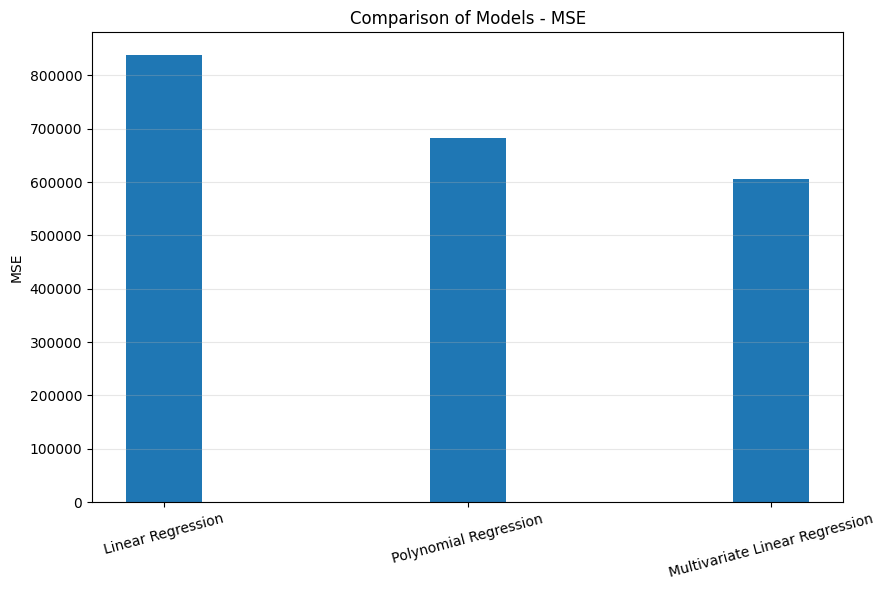

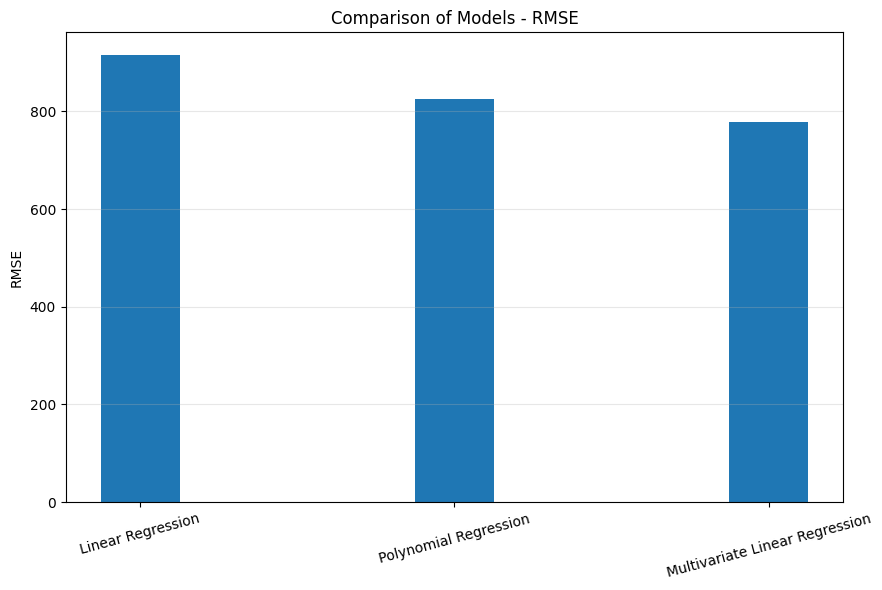

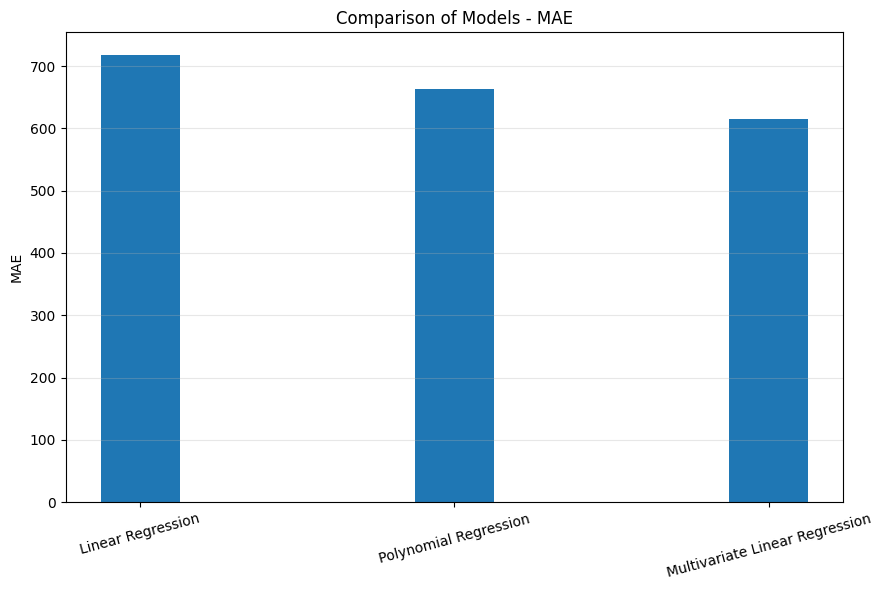

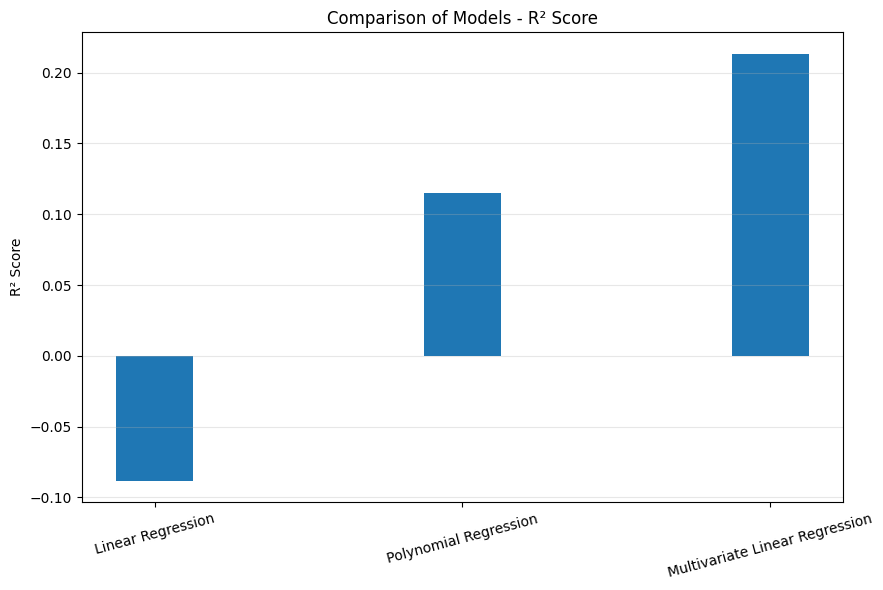

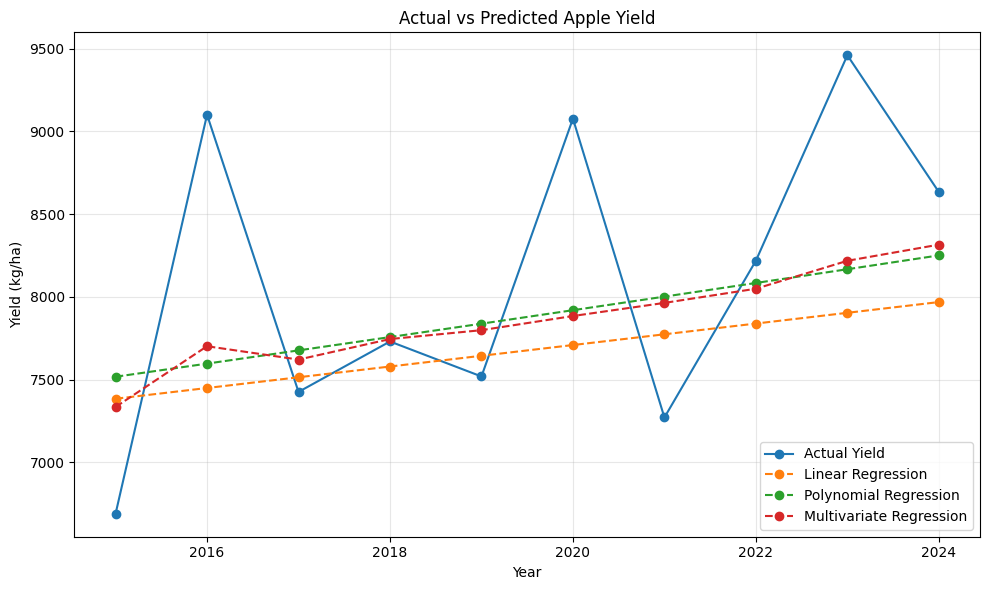



All results saved successfully!
model_comparison.csv
prediction_comparison.csv


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. LOAD DATASET
# ============================================================

CSV_PATH = "apple.csv"

df = pd.read_csv(CSV_PATH)

print("Original Dataset Shape:", df.shape)


# ============================================================
# 2. SELECT REQUIRED COLUMNS
# ============================================================

data = df[["Element", "Year", "Value"]].copy()

data["Year"] = pd.to_numeric(
    data["Year"],
    errors="coerce"
)

data["Value"] = pd.to_numeric(
    data["Value"],
    errors="coerce"
)

data = data.dropna()


# ============================================================
# 3. SEPARATE AREA HARVESTED AND YIELD
# ============================================================

area_data = data[
    data["Element"] == "Area harvested"
][["Year", "Value"]].copy()

yield_data = data[
    data["Element"] == "Yield"
][["Year", "Value"]].copy()


area_data.columns = [
    "Year",
    "Area_Harvested"
]

yield_data.columns = [
    "Year",
    "Yield"
]


# ============================================================
# 4. MERGE DATA BY YEAR
# ============================================================

data = pd.merge(
    area_data,
    yield_data,
    on="Year",
    how="inner"
)

data = data.sort_values("Year")
data = data.dropna()

print("\nProcessed Dataset:")
print(data.head())

print("\nNumber of observations:", len(data))


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

# Earlier years = training
# Later years = testing

split_year = 2014

train_data = data[
    data["Year"] <= split_year
].copy()

test_data = data[
    data["Year"] > split_year
].copy()


print("\nTraining observations:", len(train_data))
print("Testing observations :", len(test_data))


# ============================================================
# 6. FEATURES
# ============================================================

# Linear Regression
X_train_linear = train_data[["Year"]]
X_test_linear = test_data[["Year"]]


# Multivariate Regression
X_train_multi = train_data[
    ["Year", "Area_Harvested"]
]

X_test_multi = test_data[
    ["Year", "Area_Harvested"]
]


y_train = train_data["Yield"]
y_test = test_data["Yield"]


# ============================================================
# 7. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_linear,
    y_train
)

linear_pred = linear_model.predict(
    X_test_linear
)


# ============================================================
# 8. POLYNOMIAL REGRESSION
# ============================================================

POLYNOMIAL_DEGREE = 2

polynomial_model = make_pipeline(
    PolynomialFeatures(
        degree=POLYNOMIAL_DEGREE
    ),
    LinearRegression()
)

polynomial_model.fit(
    X_train_linear,
    y_train
)

polynomial_pred = polynomial_model.predict(
    X_test_linear
)


# ============================================================
# 9. MULTIVARIATE LINEAR REGRESSION
# ============================================================

multivariate_model = LinearRegression()

multivariate_model.fit(
    X_train_multi,
    y_train
)

multivariate_pred = multivariate_model.predict(
    X_test_multi
)


# ============================================================
# 10. FUNCTION FOR METRICS
# ============================================================

def calculate_metrics(actual, predicted):

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return mse, rmse, mae, r2


# ============================================================
# 11. CALCULATE METRICS FOR ALL MODELS
# ============================================================

linear_metrics = calculate_metrics(
    y_test,
    linear_pred
)

polynomial_metrics = calculate_metrics(
    y_test,
    polynomial_pred
)

multivariate_metrics = calculate_metrics(
    y_test,
    multivariate_pred
)


# ============================================================
# 12. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Multivariate Linear Regression"
    ],

    "MSE": [
        linear_metrics[0],
        polynomial_metrics[0],
        multivariate_metrics[0]
    ],

    "RMSE": [
        linear_metrics[1],
        polynomial_metrics[1],
        multivariate_metrics[1]
    ],

    "MAE": [
        linear_metrics[2],
        polynomial_metrics[2],
        multivariate_metrics[2]
    ],

    "R²": [
        linear_metrics[3],
        polynomial_metrics[3],
        multivariate_metrics[3]
    ]
})


print("\n")
print("=" * 75)
print("MODEL COMPARISON")
print("=" * 75)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 13. DETERMINE BEST MODEL
# ============================================================

# Rank each model on every metric

comparison["MSE Rank"] = (
    comparison["MSE"]
    .rank(ascending=True)
)

comparison["RMSE Rank"] = (
    comparison["RMSE"]
    .rank(ascending=True)
)

comparison["MAE Rank"] = (
    comparison["MAE"]
    .rank(ascending=True)
)

comparison["R² Rank"] = (
    comparison["R²"]
    .rank(ascending=False)
)


# Overall score
comparison["Overall Score"] = (
    comparison["MSE Rank"]
    + comparison["RMSE Rank"]
    + comparison["MAE Rank"]
    + comparison["R² Rank"]
)


best_model = comparison.loc[
    comparison["Overall Score"].idxmin(),
    "Model"
]


print("\n")
print("=" * 75)
print("BEST MODEL")
print("=" * 75)

print(
    f"Best Model: {best_model}"
)


# ============================================================
# 14. DISPLAY BEST MODEL METRICS
# ============================================================

best_row = comparison[
    comparison["Model"] == best_model
].iloc[0]

print("\nBest Model Metrics:")

print(
    f"MSE      : {best_row['MSE']:.4f}"
)

print(
    f"RMSE     : {best_row['RMSE']:.4f}"
)

print(
    f"MAE      : {best_row['MAE']:.4f}"
)

print(
    f"R² Score : {best_row['R²']:.4f}"
)


# ============================================================
# 15. ACTUAL VS PREDICTED VALUES
# ============================================================

prediction_comparison = pd.DataFrame({

    "Year": test_data["Year"].values,

    "Actual Yield": y_test.values,

    "Linear Prediction": linear_pred,

    "Polynomial Prediction": polynomial_pred,

    "Multivariate Prediction": multivariate_pred
})


print("\n")
print("=" * 75)
print("ACTUAL VS PREDICTED YIELD")
print("=" * 75)

print(
    prediction_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 16. METRIC COMPARISON GRAPH
# ============================================================

models = comparison["Model"].values

x = np.arange(len(models))

width = 0.25


# ---------------- MSE ----------------

plt.figure(figsize=(9, 6))

plt.bar(
    x,
    comparison["MSE"],
    width
)

plt.xticks(
    x,
    models,
    rotation=15
)

plt.ylabel("MSE")

plt.title(
    "Comparison of Models - MSE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "model_comparison_mse.png",
    dpi=150
)

plt.show()


# ---------------- RMSE ----------------

plt.figure(figsize=(9, 6))

plt.bar(
    x,
    comparison["RMSE"],
    width
)

plt.xticks(
    x,
    models,
    rotation=15
)

plt.ylabel("RMSE")

plt.title(
    "Comparison of Models - RMSE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "model_comparison_rmse.png",
    dpi=150
)

plt.show()


# ---------------- MAE ----------------

plt.figure(figsize=(9, 6))

plt.bar(
    x,
    comparison["MAE"],
    width
)

plt.xticks(
    x,
    models,
    rotation=15
)

plt.ylabel("MAE")

plt.title(
    "Comparison of Models - MAE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "model_comparison_mae.png",
    dpi=150
)

plt.show()


# ---------------- R² ----------------

plt.figure(figsize=(9, 6))

plt.bar(
    x,
    comparison["R²"],
    width
)

plt.xticks(
    x,
    models,
    rotation=15
)

plt.ylabel("R² Score")

plt.title(
    "Comparison of Models - R² Score"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "model_comparison_r2.png",
    dpi=150
)

plt.show()


# ============================================================
# 17. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    test_data["Year"],
    y_test,
    marker="o",
    label="Actual Yield"
)

plt.plot(
    test_data["Year"],
    linear_pred,
    marker="o",
    linestyle="--",
    label="Linear Regression"
)

plt.plot(
    test_data["Year"],
    polynomial_pred,
    marker="o",
    linestyle="--",
    label="Polynomial Regression"
)

plt.plot(
    test_data["Year"],
    multivariate_pred,
    marker="o",
    linestyle="--",
    label="Multivariate Regression"
)

plt.xlabel("Year")

plt.ylabel("Yield (kg/ha)")

plt.title(
    "Actual vs Predicted Apple Yield"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "all_models_prediction_comparison.png",
    dpi=150
)

plt.show()


# ============================================================
# 18. SAVE COMPARISON TABLE
# ============================================================

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

prediction_comparison.to_csv(
    "prediction_comparison.csv",
    index=False
)


print("\n")
print("All results saved successfully!")
print("model_comparison.csv")
print("prediction_comparison.csv")